# The Berlin Transport Network

This project seeks to analyse how the Berlin transport network affects residents across the city. We start by mapping the network, and then take on deeper analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

stations = pd.read_csv("../data/stations.csv")
routes = pd.read_csv("../data/routes.csv")
lineColours = pd.read_csv("../data/routeColours.csv")

In [2]:
stations.head()

,station,latitude,longitude
0,Neu-Westend,52.516101,13.260510
1,Senefelderplatz,52.532588,13.412608
2,Heidelberger Platz,52.480206,13.311837
3,Schwartzkopffstraße,52.535432,13.377004
4,Westhafen,52.536235,13.344020


In [3]:
stations.dtypes

station       object
latitude     float64
longitude    float64
dtype: object

In [4]:
routes.head()

,von,nach,linie
0,Hauptbahnhof,Bundestag,U5
1,Bundestag,Brandenburger Tor,U5
2,Brandenburger Tor,Unter den Linden,U5
3,Unter den Linden,Museumsinsel,U5
4,Museumsinsel,Rotes Rathaus,U5


## Mapping U- and S-Bahn stations as a network
Below is a network representation of the U- and S-Bahn network in Berlin. Trainlines are colour-coded according to their official branding.

Note: some lines overlap with each other. This means the different route colours have been drawn on top of each other, obscuring some of the routes. The differences between each of the lines will be made clearer in the map representations later.

In [5]:
G = nx.Graph()
for i, node in stations.iterrows():
    G.add_node(node["station"], pos=(node["longitude"], node["latitude"]))

for i, edge in routes.iterrows():
    # find edge colour
    routeName = edge.linie
    colourRow = lineColours[lineColours.route == routeName].iloc[0]
    rgbCol = (colourRow.r/255, colourRow.g/255, colourRow.b/255)

    # add edge to graph
    G.add_edge(edge["von"], edge["nach"], color=rgbCol)

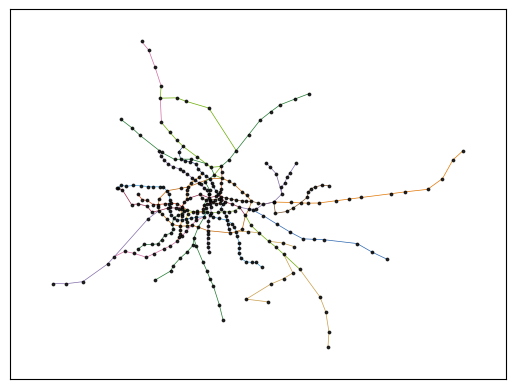

In [6]:
# plot nodes
pos = nx.get_node_attributes(G, "pos")
nx.draw_networkx_nodes(G, pos, node_size=3, node_color="black", alpha=0.8)

# plot edges and associated colours
edgeCols = list(nx.get_edge_attributes(G, "color").values())
nx.draw_networkx_edges(G, pos, edge_color=edgeCols, width=0.5, arrows=False)

## Mapping the Berlin rail network
Let's plot all the lines on a map. First, we'll create a function to plot stations, and then a function to draw the connections between them.

In the Jupyter Notebook on GitHub, this map will not be displayed properly, since Folium graphs contain hidden JavaScript. For this reason, an image of the map has been rendered instead.

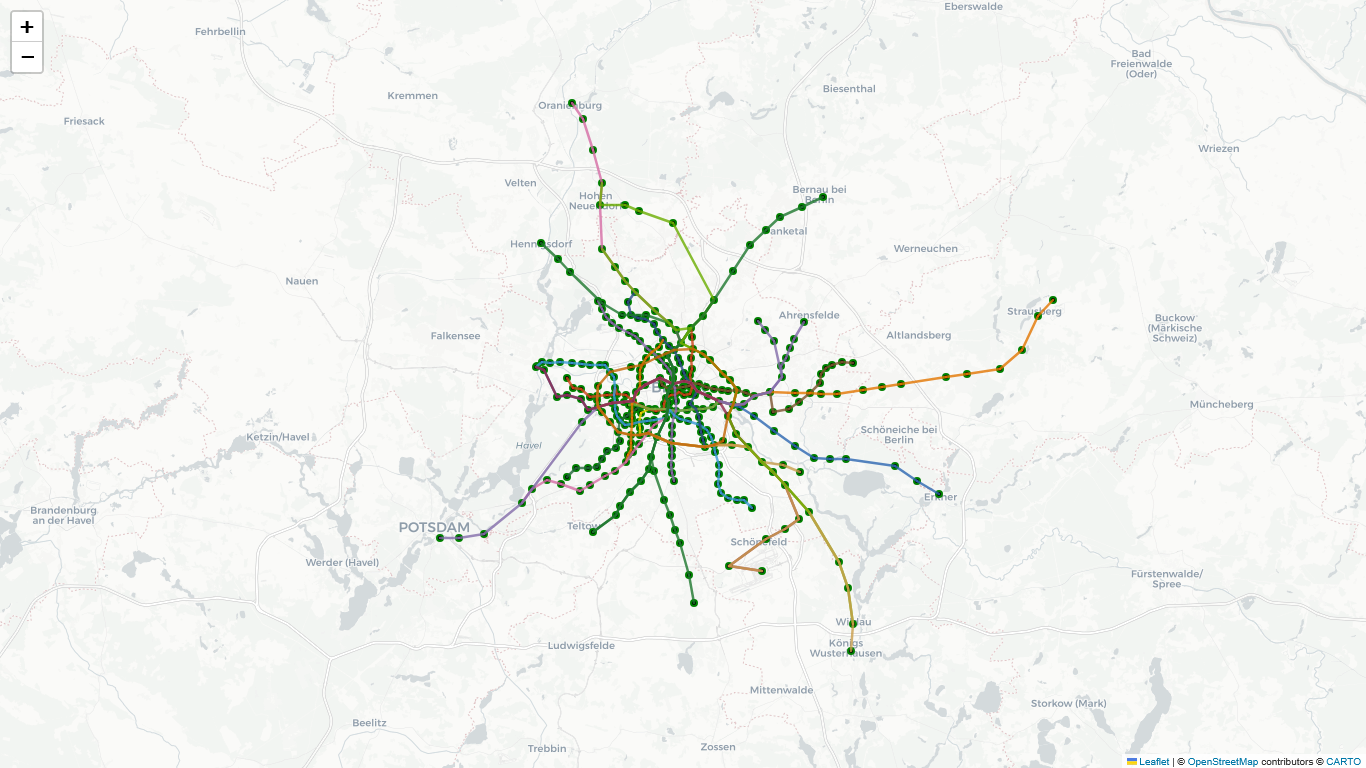

In [7]:
import folium
import webbrowser
from PIL import Image
import io

# plot points on map representing each station
def plotStations(map, stations, routes):
    for index, station in stations.iterrows():
        location = [station["latitude"], station["longitude"]]
        folium.CircleMarker(location, radius=3,
                       popup = f"Station:{station["station"]}",
                       color="green",
                       fill_color="#000000",
                       fill_opacity=1.0,
                       weight=2).add_to(map)

# draw the connections between stations
def plotTrainConnections(map, stations, routes):
    for index, route in routes.iterrows():
        # get names of stations
        station1 = stations[stations.station==route["von"]]
        station2 = stations[stations.station==route["nach"]]
    
        # get coordinates of stations
        coords1 = [station1["latitude"].iloc[0], station1["longitude"].iloc[0]]
        coords2 = [station2["latitude"].iloc[0], station2["longitude"].iloc[0]]

        # get colour based on rail line
        line = route["linie"]
        lineColour = lineColours[lineColours.route==line]
        lineColourStr = "rgb("+str(lineColour.r.item())+", "+str(lineColour.g.item())+", "+str(lineColour.b.item())+")"

        # add line to map
        folium.PolyLine([coords1, coords2], color=lineColourStr, weight=2.5, opacity=0.8).add_to(map)

def generateImage(map, imageName="myImage.png", saveImg=True):
    img_data = map._to_png(5) # 5 second delay to let tiles load
    img = Image.open(io.BytesIO(img_data))
    if saveImg:
        img.save(imageName)
    return img

# plot the map of berlin
m = folium.Map(tiles="cartodb positron", location=(52.52, 13.40), zoom_start=10)
plotStations(m, stations, routes)
plotTrainConnections(m, stations, routes)

# save as webpage
m.save("../website/static/map.html")

# display map image in jupyter
generateImage(m, saveImg=True, imageName="../python-analysis/berlinTransportNetwork.png")

Neat! We can see all the transport lines in Berlin. However, this looks like a bit of a mess with all the overlapping routes. We need the lines to be easier to read.

Let's write some code to isolate the different trainlines given some user input.

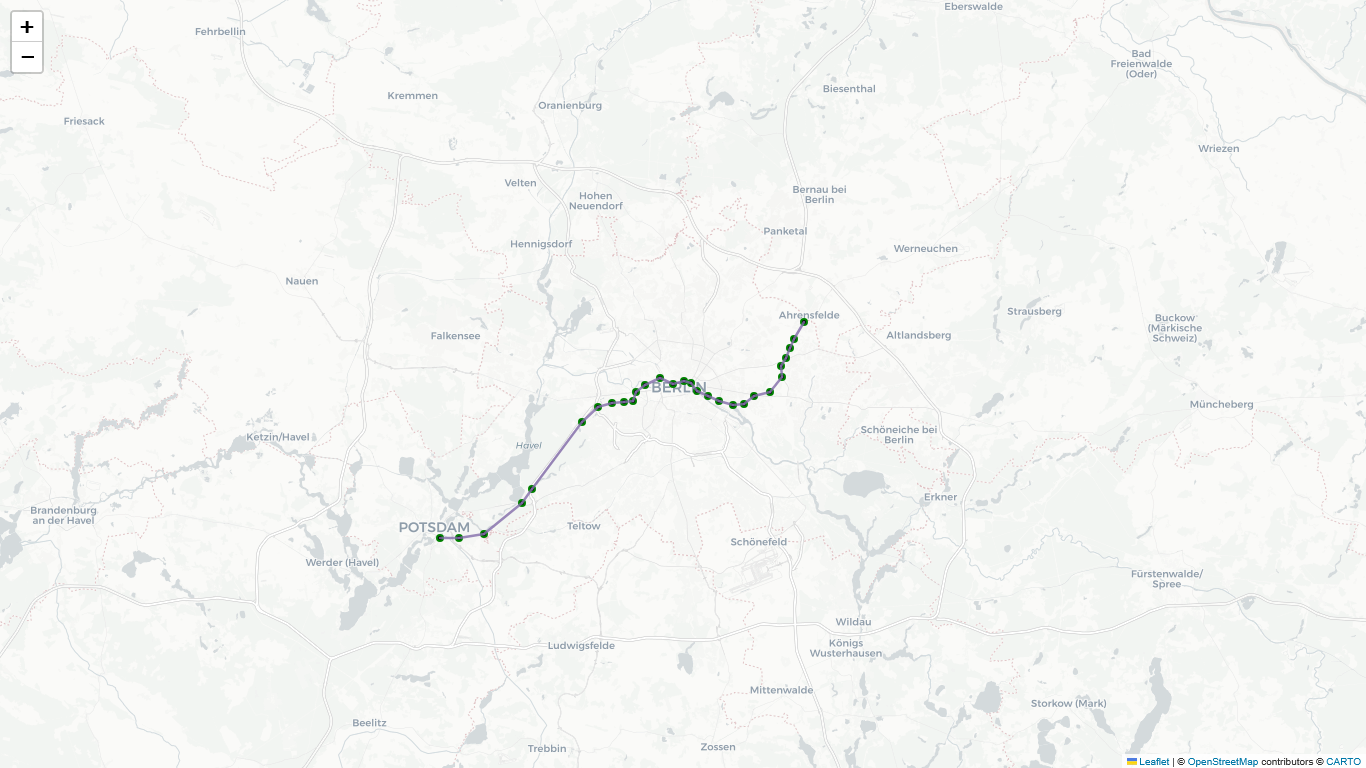

In [8]:
# function to extract train route from full dataset
def extractTrainline(stations, routes, line):
    # extract routes just on that line
    trainLine = routes[routes.linie == line]

    # get all station names on that line
    stationNames = set()
    for index, row in trainLine.iterrows():
        stationNames.add(str(row.von))
        stationNames.add(str(row.nach))
    stationNames = list(stationNames)
        
    # extract stations just on that line
    stationsSubset = stations[stations.station.isin(stationNames)]

    return stationsSubset, trainLine

# the S41 has bee excluded from the dataset because it has the same stations and routes as the S42
allBerlinLines = list(routes.linie.unique())
allBerlinLines.append("S41")

# plot subsetted map
m_sub = folium.Map(tiles="cartodb positron", location=(52.52, 13.40), zoom_start=10)

line = "S7"
while True:
    #line = input("Which line would you like to see? ").upper()
    if line in allBerlinLines:
        # double check if user entered this line
        if line == "S41":
            line = "S42"
        # plot map
        subS, subR = extractTrainline(stations, routes, line)
        plotStations(m_sub, subS, subR)
        plotTrainConnections(m_sub, subS, subR)
        break
    print("Pick one of the Berlin S-Bahn or U-Bahn lines.")

# display image in notebook rather than generating new map html
generateImage(m_sub, saveImg=False)

## Question 1: Are the elderly more cut off from the transport network?
Berlin is known as a young city, where young people go to work and party. However, there are people of all ages living in the city.

We would expect that the elderly would be situated outside of the city centre. Typically, families will move out from the centre to afford cheaper and more spacious family homes. Often, parents stay in these homes or in these areas after their children move out. For this reason, it is more likely that the elderly would be more cut off from the transport network than the young.

This could cause a social problem. Elderly people whose families have moved away may become increasingly cut off from the world, especially as their own mobility decreases. It can also be harder for the elderly to drive, meaning they would become more dependent on public transport to get groceries, socialise, and seek healthcare. If it is the case that the elderly are cut off, Berlin's local government might consider adding more stations in the cut-off regions of the city.

This data may currently be skewed as it does not consider bus and tram connections. These typically cover shorter distances and may be more relevant in the analysis of the elderly, who may take local routes to access their local amenities. The analysis will later be expanded to include this.

Data has been taken from the Amt für Statistik Berlin-Brandenburg as well as Geoportal Berlin.
1. Amt für Statistik Berlin-Brandenburg: https://www.statistik-berlin-brandenburg.de/meine-region/berlin-statistik/einwohnerbestand
2. Geodatensuche Berlin: https://gdi.berlin.de/geonetwork/srv/eng/catalog.search#/metadata/5e05b70b-50d6-4164-b0fd-9cdef4e43559

In [9]:
# import data from excel sheet
demographics = pd.read_excel("../data/EWR-Basisdaten-LOR-20241231-1-1-.xlsx", sheet_name="PLR_Absolut")
demographics.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,NaN,Geschlecht,NaN,Altersgruppen,NaN,NaN,NaN,NaN,Nationalität & Migrationshintergrund,...,NaN,NaN,NaN,NaN,Religion,NaN,NaN,Wohnlagen,NaN,NaN
3,RAUMID,Insgesamt,Einw m,Einw w,u15,15u45,45u65,65+,Durchschnittsalter,Deutsche,...,verheiratet,verwitwet,geschieden,Lebenspartnerschaft,Evangelisch,Katholisch,SonstigeKeine,einfache Wohnlage,mittlere Wohnlage,gute Wohnlage
4,01100101,3580,1869,1711,368,1734,761,717,42.863383,1999,...,1070,140,317,26,311,278,2991,0,2577,1003
5,01100102,2034,1113,921,196,1030,546,262,41.485272,941,...,839,43,137,16,138,133,1763,0,16,2018
6,01100103,5790,3073,2717,661,2698,1333,1098,42.719495,3588,...,1802,236,475,61,460,458,4872,1009,4781,0
7,01100104,4889,2587,2302,610,2645,1185,449,37.923691,2929,...,1438,77,289,29,331,314,4244,137,4752,0
8,01100205,2917,1545,1372,273,1540,613,491,41.600513,1389,...,1145,87,166,7,161,121,2635,0,0,2917
9,01100206,1876,973,903,197,900,530,249,42.168449,1202,...,621,58,156,19,120,151,1605,0,0,1876


Let's remove the rows that are empty in this dataset. That is, rows 0 to 2 and everything after 547. The labels in row three also need to be converted into the column names.

In [10]:
# rename columns
demographics = demographics.rename(columns=demographics.loc[3])

# remove blank rows
demographics.drop([0,1,2,3,547,548,549,550,551,552], inplace=True)

# reset row numbers
demographics = demographics.reset_index()

# show dmographics table
demographics

,index,RAUMID,Insgesamt,Einw m,Einw w,u15,15u45,45u65,65+,Durchschnittsalter,...,verheiratet,verwitwet,geschieden,Lebenspartnerschaft,Evangelisch,Katholisch,SonstigeKeine,einfache Wohnlage,mittlere Wohnlage,gute Wohnlage
0,4,01100101,3580,1869,1711,368,1734,761,717,42.863383,...,1070,140,317,26,311,278,2991,0,2577,1003
1,5,01100102,2034,1113,921,196,1030,546,262,41.485272,...,839,43,137,16,138,133,1763,0,16,2018
2,6,01100103,5790,3073,2717,661,2698,1333,1098,42.719495,...,1802,236,475,61,460,458,4872,1009,4781,0
3,7,01100104,4889,2587,2302,610,2645,1185,449,37.923691,...,1438,77,289,29,331,314,4244,137,4752,0
4,8,01100205,2917,1545,1372,273,1540,613,491,41.600513,...,1145,87,166,7,161,121,2635,0,0,2917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,542,12601133,11448,5550,5898,2121,4538,2632,2157,40.607074,...,3722,755,1145,6,1431,1142,8875,9074,2374,0
539,543,12601134,16006,7699,8307,3024,6054,3610,3318,41.257089,...,5537,1133,1421,10,2125,1428,12453,7062,8944,0
540,544,12601235,10610,5215,5395,2086,4375,2465,1684,38.855176,...,3670,566,881,12,1040,932,8638,8280,2330,0
541,545,12601236,3190,1601,1589,380,1099,837,874,46.64411,...,1459,217,209,3,367,293,2530,422,2768,0


Let's also remove the last row from the data, which shows the totals for the whole of Berlin. This is not directly relevant for our dicussion at the moment.

In [11]:
demographics.drop([542], inplace=True)

Now let's convert the datatypes so that the columns can be analysed accurately in pandas.

In [12]:
demographics.dtypes

index                           int64
RAUMID                         object
Insgesamt                      object
Einw m                         object
Einw w                         object
u15                            object
15u45                          object
45u65                          object
65+                            object
Durchschnittsalter             object
Deutsche                       object
Ausländer                      object
Einwohner ohne Migra           object
Einwohner mit Migra            object
darunter Deutsche mit Migra    object
ledig                          object
verheiratet                    object
verwitwet                      object
geschieden                     object
Lebenspartnerschaft            object
Evangelisch                    object
Katholisch                     object
SonstigeKeine                  object
einfache Wohnlage              object
mittlere Wohnlage              object
gute Wohnlage                  object
dtype: objec

All the datastypes in this dataset appear to be objects. Since most columns contain numerical data we will have to transform these columns accordingly.
- **RAUMID** (location ID) will be converted to a string, since this describes the location category. Additionally, this helps manipulate the final column in which the RAUMID is 'Berlin' instead of a number.
- **Insgesamt** (total) this is the total number of people in each region.
- **Einw m** (male residents) describes the number of residents who are male. This is discrete numerical data so should be an integer.
- **Einw w** (female residents) describes the number of female residents in each region. Similarly, this discrete numerical data should be an integer.

- **u15** (under 15s) describes the number of people under the age of 15 in the region. This is integer data.
- **15u45** (15-45 year olds) describes the number of people in the region between the age of 15 and 45 and is integer data.
- **45u65** (45-65 year olds) describes the number of people ages between 45 and 65 and should be an integer.
- **65+** (over 65s) records the number of over 65s in each region and is integer data.
  
- **Durchschnittsalter** (average age) record the average in each region. This is continous numerical data so should be a float.
- **Deutsche** (Germans) counts the number of Germans in each region and is integer data.
- **Ausländer** (foreigners) is the number of foreigners in each region and is integer data.
- **Einwohner** ohne Migra (residents without foreign heritage) counts the number of local residents with no foreign heritage and is integer data.
- **Einwohner mit Migra** (residents with foreign heritage) describes the number of local residents with foreign heritage and is integer data.
- **darunter Deutsche mit Migra** (within that Germans with foreign heritage) is the number of local residents who are German and have foreign heritage. This is integer data.

- **ledig** (single) describes the number of single people in the region. This is integer data.
- **verheriratet** (married) counts the number of married people in the region. This is integer data.
- **verwitwet** (widowed) is the number of people who have been widowed, which is integer data.
- **geschieden** (separated/divorced) counts the number of people who have divorced in each region. This is an integer.
- **Lebenspartnerschaft** (civil partnership) is the number of civil partners in each region. This is integer data.

- **Evangelisch** (evangelical) is the number of people registered as evangelical Christians, which is integer data.
- **Katholisch** (catholic) represents the number of people registered as Catholic, which is integer data.
- **SonstigeKeine** (other/none) represents the number of people registered as having no religion or another religion. Note that in Germany, data an on religion is only collected to ensure Christians pay extra tax to the Church. There may be many Evangelical of Catholic Christians contained in this other/none category if they want to avoid paying extra tax. This is numerical integer data.


- **einfache Wohnlage** (basic residential area) counts the number of people in the poorest quality type of housing.
- **mittlere Wohnlage** (medium-quality residential area) is th number of residents living in mid-tier housing.
- **gute Wohnlage** (premium residential area) represents the number of people living in exceptionally good housing.

In [13]:
# convert location ID to an integer
demographics["RAUMID"] = demographics["RAUMID"].astype("str")

# convert total column
demographics["Insgesamt"] = demographics["Insgesamt"].astype("int")

# convert sex data
demographics["Einw m"] = demographics["Einw m"].astype("int")
demographics["Einw w"] = demographics["Einw w"].astype("int")

# convert age data
demographics["u15"] = demographics["u15"].astype("int")
demographics["15u45"] = demographics["15u45"].astype("int")
demographics["45u65"] = demographics["45u65"].astype("int")
demographics["65+"] = demographics["65+"].astype("int")
demographics["Durchschnittsalter"] = demographics["Durchschnittsalter"].astype("float")

# convert hertitage data
demographics["Deutsche"] = demographics["Deutsche"].astype("int")
demographics["Ausländer"] = demographics["Ausländer"].astype("int")
demographics["Einwohner ohne Migra"] = demographics["Einwohner ohne Migra"].astype("int")
demographics["Einwohner mit Migra"] = demographics["Einwohner mit Migra"].astype("int")
demographics["darunter Deutsche mit Migra"] = demographics["darunter Deutsche mit Migra"].astype("int")

# convert marital status data
demographics["ledig"] = demographics["ledig"].astype("int")
demographics["verheiratet"] = demographics["verheiratet"].astype("int")
demographics["verwitwet"] = demographics["verwitwet"].astype("int")
demographics["geschieden"] = demographics["geschieden"].astype("int")
demographics["Lebenspartnerschaft"] = demographics["Lebenspartnerschaft"].astype("int")

# convert religion data
demographics["Evangelisch"] = demographics["Evangelisch"].astype("int")
demographics["Katholisch"] = demographics["Katholisch"].astype("int")
demographics["SonstigeKeine"] = demographics["SonstigeKeine"].astype("int")

# convert living situation data
demographics["einfache Wohnlage"] = demographics["einfache Wohnlage"].astype("int")
demographics["mittlere Wohnlage"] = demographics["mittlere Wohnlage"].astype("int")
demographics["gute Wohnlage"] = demographics["gute Wohnlage"].astype("int")

In [14]:
demographics.dtypes

index                            int64
RAUMID                          object
Insgesamt                        int32
Einw m                           int32
Einw w                           int32
u15                              int32
15u45                            int32
45u65                            int32
65+                              int32
Durchschnittsalter             float64
Deutsche                         int32
Ausländer                        int32
Einwohner ohne Migra             int32
Einwohner mit Migra              int32
darunter Deutsche mit Migra      int32
ledig                            int32
verheiratet                      int32
verwitwet                        int32
geschieden                       int32
Lebenspartnerschaft              int32
Evangelisch                      int32
Katholisch                       int32
SonstigeKeine                    int32
einfache Wohnlage                int32
mittlere Wohnlage                int32
gute Wohnlage            

Now let's look for missing data points and try to correct for missing data so it does not harm our analysis.

In [15]:
pd.isna(demographics)

,index,RAUMID,Insgesamt,Einw m,Einw w,u15,15u45,45u65,65+,Durchschnittsalter,...,verheiratet,verwitwet,geschieden,Lebenspartnerschaft,Evangelisch,Katholisch,SonstigeKeine,einfache Wohnlage,mittlere Wohnlage,gute Wohnlage
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
540,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Now let's associate the RAUMIDs with their area names.

In [16]:
plr_names = pd.read_excel("../data/lor_2021-01-01_k3_uebersicht_id_namen.xlsx", sheet_name="LOR_2023_Übersicht")

# extract just the ID and name
plr_names = plr_names[["PLR_ID", "PLR"]]

# convert the ID to be a string
plr_names["PLR_ID"] = plr_names["PLR_ID"].astype("str")

# display table
plr_names

,PLR_ID,PLR
0,1100101,Stülerstraße
1,1100102,Großer Tiergarten
2,1100103,Lützowstraße
3,1100104,Körnerstraße
4,1100205,Wilhelmstraße
...,...,...
537,12601032,Rollbergesiedlung
538,12601133,Treuenbrietzener Straße
539,12601134,Märkisches Zentrum
540,12601235,Dannenwalder Weg


In [17]:
# join RAUMUID on PLR_ID and drop additional column
demographics = demographics.merge(plr_names, left_on="RAUMID", right_on="PLR_ID", how="left")
demographics.drop(columns=["PLR_ID", "index"], inplace=True)

# now let's rename the PLR column
demographics.rename(columns={"Location":"PLR"}, inplace=True)

# display the table
demographics

,RAUMID,Insgesamt,Einw m,Einw w,u15,15u45,45u65,65+,Durchschnittsalter,Deutsche,...,verwitwet,geschieden,Lebenspartnerschaft,Evangelisch,Katholisch,SonstigeKeine,einfache Wohnlage,mittlere Wohnlage,gute Wohnlage,PLR
0,01100101,3580,1869,1711,368,1734,761,717,42.863383,1999,...,140,317,26,311,278,2991,0,2577,1003,NaN
1,01100102,2034,1113,921,196,1030,546,262,41.485272,941,...,43,137,16,138,133,1763,0,16,2018,NaN
2,01100103,5790,3073,2717,661,2698,1333,1098,42.719495,3588,...,236,475,61,460,458,4872,1009,4781,0,NaN
3,01100104,4889,2587,2302,610,2645,1185,449,37.923691,2929,...,77,289,29,331,314,4244,137,4752,0,NaN
4,01100205,2917,1545,1372,273,1540,613,491,41.600513,1389,...,87,166,7,161,121,2635,0,0,2917,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,12601032,6250,3121,3129,1351,2531,1359,1009,38.259520,4030,...,294,518,3,801,521,4928,5358,892,0,Rollbergesiedlung
538,12601133,11448,5550,5898,2121,4538,2632,2157,40.607074,8329,...,755,1145,6,1431,1142,8875,9074,2374,0,Treuenbrietzener Straße
539,12601134,16006,7699,8307,3024,6054,3610,3318,41.257089,11749,...,1133,1421,10,2125,1428,12453,7062,8944,0,Märkisches Zentrum
540,12601235,10610,5215,5395,2086,4375,2465,1684,38.855176,7285,...,566,881,12,1040,932,8638,8280,2330,0,Dannenwalder Weg


Now that we've cleaned the demographics data, let's plot a chloropleth map showing average age across each area in Berlin.

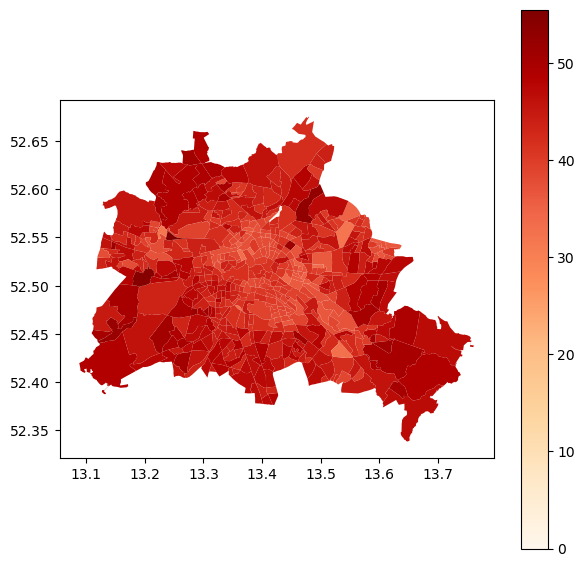

In [18]:
import geopandas as gpd

# load geographic data
gdf = gpd.read_file("../data/a_lor_plr_2021.gpkg")

# merge geographic data with demographics df
merged = gdf.merge(demographics, left_on="plr_id", right_on="RAUMID")

# update map projection to be folium friendly
merged = merged.to_crs(epsg=4326)

merged.plot(
    column="Durchschnittsalter", # demographic variable
    cmap="OrRd",
    legend=True,
    figsize=(7, 7)
)
plt.show()

This suggests that average age is higher further outside the city centre. Let's compare average age within and outside the Ringbahn, a ring that separates the city centre from Berlin's outskirts. This will give us a rough idea if age changes significantly where there are significantly fewer S-Bahn routes.

In [19]:
# create a subset of the stations df containing just the Ringbahn
subsetRingbahnStations, subsetRingbahnRoute = extractTrainline(stations, routes, "S42")

# create a GeoDataFrame with the Ringbahn latitudes and longitudes
geopd_latslongs = gpd.GeoDataFrame(subsetRingbahnStations, geometry=gpd.points_from_xy(subsetRingbahnStations.longitude, subsetRingbahnStations.latitude))
geopd_latslongs.head()

,station,latitude,longitude,geometry
2,Heidelberger Platz,52.480206,13.311837,POINT (13.31184 52.48021)
4,Westhafen,52.536235,13.344020,POINT (13.34402 52.53624)
20,Jungfernheide,52.530693,13.300498,POINT (13.3005 52.53069)
28,Bundesplatz,52.477608,13.328596,POINT (13.3286 52.47761)
29,Innsbrucker Platz,52.478068,13.342072,POINT (13.34207 52.47807)


Text(0.5, 1.0, 'Average age in Berlin by region')

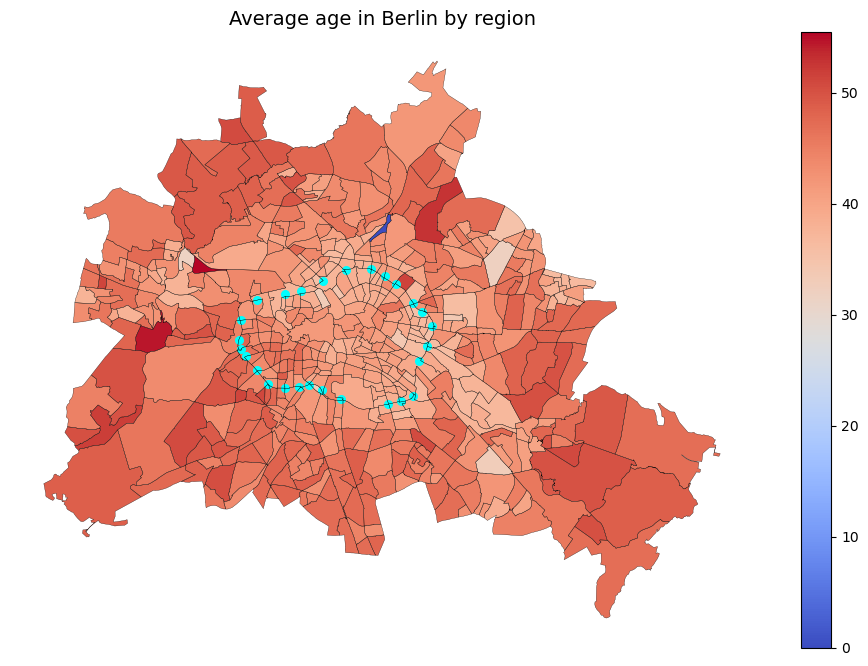

In [20]:
# change map projection for both the chloropleth map and the lats/longs
merged = merged.to_crs(epsg=4326)
geopd_latslongs = geopd_latslongs.set_crs(epsg=4326)

# plot map of average age like before
fig, ax = plt.subplots(figsize=(12, 8))

merged.plot(
    column="Durchschnittsalter", # demographic variable
    cmap="coolwarm",
    legend=True,
    ax=ax
)

merged.boundary.plot(ax=ax, color="black", linewidth=0.2)

# plot stations on the Ringbahn
geopd_latslongs.plot(ax=ax, color="cyan", markersize=30)

# add title and remove border
ax.set_axis_off()
ax.set_title("Average age in Berlin by region", fontsize=14)

While age does appear to be higher outside the Ringbahn - there is no distinctive difference between the inside and outside of the route. Instead, age gradually increases as you move further out from the centre.